In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [106]:
train_data = pd.read_csv('Data/loans_train.csv')
valid_data = pd.read_csv('Data/loans_valid.csv')
test_data = pd.read_csv('Data/loans_test.csv')

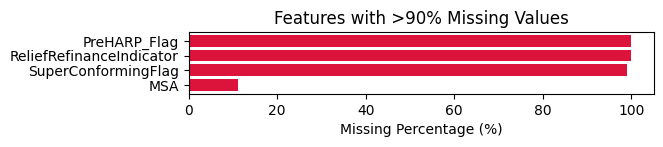

In [107]:
missing_counts = train_data.isna().sum()
missing_pct = (missing_counts / len(train_data)) * 100

# Keep only features with >90% missing
missing_df = pd.DataFrame({
    "Feature": missing_counts.index,
    "Missing %": missing_pct
})
missing_df = missing_df[missing_df["Missing %"] != 0].sort_values("Missing %", ascending=False)

# Plot
if not missing_df.empty:
    plt.figure(figsize=(6,0.8))
    plt.barh(missing_df["Feature"], missing_df["Missing %"], color="crimson")
    plt.xlabel("Missing Percentage (%)")
    plt.title("Features with >90% Missing Values")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No features with more than 90% missing values.")

In [108]:
train_data = train_data.drop(columns=['PreHARP_Flag', 'ReliefRefinanceIndicator'])
valid_data = valid_data.drop(columns=['PreHARP_Flag', 'ReliefRefinanceIndicator'])
test_data = test_data.drop(columns=['PreHARP_Flag', 'ReliefRefinanceIndicator'])

train_data['SuperConformingFlag'] = train_data['SuperConformingFlag'].replace(np.nan, 'N')
valid_data['SuperConformingFlag'] = valid_data['SuperConformingFlag'].replace(np.nan, 'N')
test_data['SuperConformingFlag'] = test_data['SuperConformingFlag'].replace(np.nan, 'N')

train_data['MSA'] = train_data['MSA'].replace(np.nan, 'Other')
valid_data['MSA'] = valid_data['MSA'].replace(np.nan, 'Other')
test_data['MSA'] = test_data['MSA'].replace(np.nan, 'Other')

In [109]:
print((train_data['CreditScore'] == 9999).sum())
print((train_data['MI_Pct'] == 999).sum())
print((train_data['OriginalDTI'] == 999).sum())
print((train_data['OriginalLTV'] == 999).sum())

for col in train_data.columns:
    if '_' in col:
        sp = col.split('_')
        if sp[1] == 'EstimatedLTV':
            print(col, ":", (train_data[col] == 999).sum())

8
0
1
0
0_EstimatedLTV : 10806
1_EstimatedLTV : 2117
2_EstimatedLTV : 2070
3_EstimatedLTV : 1905
4_EstimatedLTV : 1903
5_EstimatedLTV : 1911
6_EstimatedLTV : 1899
7_EstimatedLTV : 1879
8_EstimatedLTV : 1872
9_EstimatedLTV : 1866
10_EstimatedLTV : 1843
11_EstimatedLTV : 1857
12_EstimatedLTV : 1847
13_EstimatedLTV : 2036


In [110]:
train_data['CreditScore_MissFLag'] = (train_data['CreditScore'] == 9999).astype(int)
med = train_data.loc[train_data['CreditScore'] != 9999, 'CreditScore'].median()
train_data['CreditScore'] = train_data['CreditScore'].replace(9999, med)

valid_data['CreditScore_MissFLag'] = (valid_data['CreditScore'] == 9999).astype(int)
med = valid_data.loc[valid_data['CreditScore'] != 9999, 'CreditScore'].median()
valid_data['CreditScore'] = valid_data['CreditScore'].replace(9999, med)

test_data['CreditScore_MissFLag'] = (test_data['CreditScore'] == 9999).astype(int)
med = test_data.loc[test_data['CreditScore'] != 9999, 'CreditScore'].median()
test_data['CreditScore'] = test_data['CreditScore'].replace(9999, med)

train_data['OriginalDTI_MissFLag'] = (train_data['OriginalDTI'] == 999).astype(int)
med = train_data.loc[train_data['OriginalDTI'] != 999, 'OriginalDTI'].median()
train_data['OriginalDTI'] = train_data['OriginalDTI'].replace(999, med)

valid_data['OriginalDTI_MissFLag'] = (valid_data['OriginalDTI'] == 999).astype(int)
med = valid_data.loc[valid_data['OriginalDTI'] != 999, 'OriginalDTI'].median()
valid_data['OriginalDTI'] = valid_data['OriginalDTI'].replace(999, med)

test_data['OriginalDTI_MissFLag'] = (test_data['OriginalDTI'] == 999).astype(int)
med = test_data.loc[test_data['OriginalDTI'] != 999, 'OriginalDTI'].median()
test_data['OriginalDTI'] = test_data['OriginalDTI'].replace(999, med)

In [111]:
ltv_cols = [col for col in train_data.columns if '_EstimatedLTV' in col]

train_data.loc[:, ltv_cols] = train_data.loc[:, ltv_cols].replace(999, np.nan)
valid_data.loc[:, ltv_cols] = valid_data.loc[:, ltv_cols].replace(999, np.nan)
test_data.loc[:, ltv_cols] = test_data.loc[:, ltv_cols].replace(999, np.nan)

/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/2844965387.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 67. 72. ... nan nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[:, ltv_cols] = train_data.loc[:, ltv_cols].replace(999, np.nan)
/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/2844965387.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 66. 73. ... nan nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[:, ltv_cols] = train_data.loc[:, ltv_cols].replace(999, np.nan)
/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/2844965387.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[n

In [112]:
constant_cols = []

for col in train_data.columns:
      if train_data[col].nunique() == 1:
          constant_cols.append(col)

constant_cols.remove('target')

constant_cols

['PPM_Flag',
 'ProductType',
 'InterestOnlyFlag',
 '0_CurrentNonInterestBearingUPB',
 '0_MonthlyReportingPeriod',
 '1_CurrentNonInterestBearingUPB',
 '1_MonthlyReportingPeriod',
 '2_CurrentNonInterestBearingUPB',
 '2_MonthlyReportingPeriod',
 '3_CurrentNonInterestBearingUPB',
 '3_MonthlyReportingPeriod',
 '4_CurrentNonInterestBearingUPB',
 '4_MonthlyReportingPeriod',
 '5_CurrentNonInterestBearingUPB',
 '5_MonthlyReportingPeriod',
 '6_CurrentNonInterestBearingUPB',
 '6_MonthlyReportingPeriod',
 '7_CurrentNonInterestBearingUPB',
 '7_MonthlyReportingPeriod',
 '8_CurrentNonInterestBearingUPB',
 '8_MonthlyReportingPeriod',
 '9_CurrentNonInterestBearingUPB',
 '9_MonthlyReportingPeriod',
 '10_CurrentNonInterestBearingUPB',
 '10_MonthlyReportingPeriod',
 '11_CurrentNonInterestBearingUPB',
 '11_MonthlyReportingPeriod',
 '12_CurrentNonInterestBearingUPB',
 '12_MonthlyReportingPeriod',
 '13_CurrentNonInterestBearingUPB',
 '13_MonthlyReportingPeriod']

In [113]:
train_data = train_data.drop(columns = constant_cols)
valid_data = valid_data.drop(columns = constant_cols)
test_data = test_data.drop(columns = constant_cols)

In [114]:
train_data = train_data.drop(columns = ['FirstPaymentDate', 'MaturityDate', 'PostalCode'])
valid_data = valid_data.drop(columns = ['FirstPaymentDate', 'MaturityDate', 'PostalCode'])
test_data = test_data.drop(columns = ['FirstPaymentDate', 'MaturityDate', 'PostalCode'])

In [115]:
for col in train_data.columns:
    print(col)

index
target
CreditScore
FirstTimeHomebuyerFlag
MSA
MI_Pct
NumberOfUnits
OccupancyStatus
OriginalCLTV
OriginalDTI
OriginalUPB
OriginalLTV
OriginalInterestRate
Channel
PropertyState
PropertyType
LoanPurpose
OriginalLoanTerm
NumberOfBorrowers
SellerName
ServicerName
SuperConformingFlag
ProgramIndicator
PropertyValMethod
BalloonIndicator
0_CurrentActualUPB
0_CurrentInterestRate
0_EstimatedLTV
0_InterestBearingUPB
0_LoanAge
0_RemainingMonthsToLegalMaturity
1_CurrentActualUPB
1_CurrentInterestRate
1_EstimatedLTV
1_InterestBearingUPB
1_LoanAge
1_RemainingMonthsToLegalMaturity
2_CurrentActualUPB
2_CurrentInterestRate
2_EstimatedLTV
2_InterestBearingUPB
2_LoanAge
2_RemainingMonthsToLegalMaturity
3_CurrentActualUPB
3_CurrentInterestRate
3_EstimatedLTV
3_InterestBearingUPB
3_LoanAge
3_RemainingMonthsToLegalMaturity
4_CurrentActualUPB
4_CurrentInterestRate
4_EstimatedLTV
4_InterestBearingUPB
4_LoanAge
4_RemainingMonthsToLegalMaturity
5_CurrentActualUPB
5_CurrentInterestRate
5_EstimatedLTV
5_Inter

In [116]:
from sklearn.linear_model import LinearRegression

# ---------- Helper Functions ----------
def compute_slope(series):
    """Compute linear regression slope (ignoring NaNs)."""
    y = np.array(series, dtype=float)
    mask = np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    x = np.arange(mask.sum()).reshape(-1, 1)
    model = LinearRegression().fit(x, y[mask])
    return model.coef_[0]

def autocorr(x):
    x = pd.Series(x).dropna()
    return x.autocorr(1) if len(x) > 2 else np.nan

def get_longest_non_decreasing_streak(row):
    """Longest consecutive streak of non-decreasing values in a row."""
    diffs = row.diff().dropna()
    streak = max_streak = 0
    for val in diffs >= 0:
        if val:
            streak += 1
        else:
            max_streak = max(max_streak, streak)
            streak = 0
    return max(max_streak, streak)


# ---------- Main Function ----------
def derive_full_temporal_features(df, months=range(14)):
    """
    Combines user-defined temporal repayment features and extended amortization,
    LTV, and interest-rate behavior features for Freddie Mac panel data.
    """

    # --- Column groups ---
    upb_cols = [f"{m}_CurrentActualUPB" for m in months]
    ltv_cols = [f"{m}_EstimatedLTV" for m in months if f"{m}_EstimatedLTV" in df.columns]
    rate_cols = [f"{m}_CurrentInterestRate" for m in months if f"{m}_CurrentInterestRate" in df.columns]
    rem_cols = [f"{m}_RemainingMonthsToLegalMaturity" for m in months if f"{m}_RemainingMonthsToLegalMaturity" in df.columns]
    intb_cols = [f"{m}_InterestBearingUPB" for m in months if f"{m}_InterestBearingUPB" in df.columns]

    # ========== USER’S ORIGINAL FEATURES ==========
    # Month-on-month % UPB difference
    upb_diff = pd.DataFrame({
        f"{i}_{i+1}_UPB_Diff": ((df[upb_cols[i]] - df[upb_cols[i+1]]) / df[upb_cols[i]]) * 100
        for i in range(len(upb_cols) - 1)
    })

    df = pd.concat([df, upb_diff], axis=1)

    # UPB volatility, trend, and range
    df["UPB_std"] = df[upb_cols].std(axis=1)
    df["UPB_trend"] = df[upb_cols[-1]] - df[upb_cols[0]]
    df["UPB_trend_pct"] = ((df[upb_cols[-1]] - df[upb_cols[0]]) / df[upb_cols[0]]) * 100
    df["UPB_range"] = df[upb_cols].max(axis=1) - df[upb_cols].min(axis=1)

    # Longest streak of non-decreasing UPB (unchanged or increased)
    df["longest_unchanged_UPB"] = df[upb_cols].apply(get_longest_non_decreasing_streak, axis=1)

    # Repayment ratio features
    repayment_ratios = 1 - df[upb_cols].div(df["OriginalUPB"], axis=0)
    df["avg_repayment_ratio"] = repayment_ratios.mean(axis=1)
    df["std_repayment_ratio"] = repayment_ratios.std(axis=1)
    is_late = repayment_ratios.diff(axis=1) <= 0
    df["pct_months_late"] = is_late.sum(axis=1) / len(upb_cols)

    # Repayment trend slope
    months_idx = np.arange(len(upb_cols)).reshape(-1, 1)
    slopes = []
    for i in range(len(df)):
        y = repayment_ratios.iloc[i].values
        mask = np.isfinite(y)
        if mask.sum() < 2:
            slopes.append(np.nan)
        else:
            model = LinearRegression().fit(months_idx[mask], y[mask])
            slopes.append(model.coef_[0])
    df["repayment_trend_slope"] = slopes

    # ========== ADDITIONAL ADVANCED FEATURES ==========
    upb = df[upb_cols].to_numpy(dtype=float)

    # 1️⃣ Amortization / principal reduction
    with np.errstate(divide="ignore", invalid="ignore"):
        df["UPB_first_to_last_ratio"] = upb[:, -1] / upb[:, 0]
        df["Principal_reduction_rate"] = (upb[:, 0] - upb[:, -1]) / upb[:, 0]
        df["UPB_volatility"] = np.nanstd(np.diff(upb, axis=1) / np.clip(upb[:, :-1], 1e-6, None), axis=1)
    df["Amortization_slope"] = [compute_slope(u) for u in upb]
    df["UPB_rebound_count"] = np.sum(np.diff(upb, axis=1) > 0, axis=1)
    df["UPB_autocorr"] = [autocorr(u) for u in upb]
    df["UPB_skew"] = pd.DataFrame(upb).skew(axis=1)
    df["UPB_kurtosis"] = pd.DataFrame(upb).kurtosis(axis=1)

    # 2️⃣ LTV evolution
    if ltv_cols:
        ltv = df[ltv_cols].to_numpy(dtype=float)
        df["LTV_mean"] = np.nanmean(ltv, axis=1)
        df["LTV_std"] = np.nanstd(ltv, axis=1)
        df["LTV_slope"] = [compute_slope(l) for l in ltv]
        df["LTV_range"] = np.nanmax(ltv, axis=1) - np.nanmin(ltv, axis=1)
        df["LTV_rebound_count"] = np.sum(np.diff(ltv, axis=1) > 0, axis=1)

    # 3️⃣ Interest-rate behavior
    if rate_cols:
        rate = df[rate_cols].to_numpy(dtype=float)
        df["Interest_rate_std"] = np.nanstd(rate, axis=1)
        df["Interest_rate_change_count"] = np.sum(np.diff(rate, axis=1) != 0, axis=1)
        df["Interest_rate_slope"] = [compute_slope(r) for r in rate]

    # 4️⃣ Remaining-months consistency
    if rem_cols:
        rem = df[rem_cols].to_numpy(dtype=float)
        df["RemainingMonths_slope"] = [compute_slope(r) for r in rem]
        df["RemainingMonths_std"] = np.nanstd(np.diff(rem, axis=1), axis=1)
        df["LoanAge_gap_flag"] = np.sum(np.abs(np.diff(rem, axis=1) + 1) > 1e-3, axis=1) > 0

    # 5️⃣ Interest-bearing structure
    if intb_cols:
        intb = df[intb_cols].to_numpy(dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            df["InterestBearing_ratio"] = np.nanmean(intb / upb, axis=1)
        df["NonInterestBearing_trend"] = [compute_slope(upb[i] - intb[i]) for i in range(len(df))]

    # 6️⃣ Early repayment ratio (front-loaded prepayment)
    mid = len(months) // 2
    with np.errstate(divide="ignore", invalid="ignore"):
        early_reduction = upb[:, 0] - upb[:, mid]
        total_reduction = upb[:, 0] - upb[:, -1]
        df["Early_repayment_ratio"] = np.divide(early_reduction, total_reduction)
        df["Early_repayment_ratio"] = df["Early_repayment_ratio"].clip(0, 5)

    # 7️⃣ Cross-metric risk interactions
    if {"CreditScore", "OriginalLTV", "OriginalDTI"}.issubset(df.columns):
        df["CreditScore_LTV_Ratio"] = df["CreditScore"] / df["OriginalLTV"].replace(0, np.nan)
        df["CreditScore_DTI_Ratio"] = df["CreditScore"] / df["OriginalDTI"].replace(0, np.nan)
        df["LTV_DTI_Product"] = (df["OriginalLTV"] * df["OriginalDTI"]) / 10000

    # 8️⃣ Clean infinities
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df

def risk_features(df):
    # Debt Service Ratio - actual monthly debt burden considering interest rates
    df['DebtServiceRatio'] = df['OriginalDTI'] * df['OriginalInterestRate'] / 100

    # Risk categories
    df['HighRiskCredit'] = (df['CreditScore'] < 620).astype(int)
    df['HighLTV'] = (df['OriginalLTV'] > 80).astype(int)
    df['HighDTI'] = (df['OriginalDTI'] > 43).astype(int)
    df['HighInterestRate'] = (df['OriginalInterestRate'] > 7).astype(int)

    # Combined risk score
    df['CompositeRiskScore'] = (df['HighRiskCredit'] + 
                                        df['HighLTV'] + 
                                        df['HighDTI'] + 
                                        df['HighInterestRate'])
    
    return df


In [117]:
df_train = derive_full_temporal_features(train_data)
df_valid = derive_full_temporal_features(valid_data)
df_test = derive_full_temporal_features(test_data)

df_train = risk_features(df_train)
df_valid = risk_features(df_valid)
df_test = risk_features(df_test)

/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/2072361953.py:100: RuntimeWarning: Mean of empty slice
  df["LTV_mean"] = np.nanmean(ltv, axis=1)
/Users/aviralgoyal/Desktop/NUS/Courses/CS5344_Big_Data_Technology/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/2072361953.py:103: RuntimeWarning: All-NaN slice encountered
  df["LTV_range"] = np.nanmax(ltv, axis=1) - np.nanmin(ltv, axis=1)
/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/2072361953.py:100: RuntimeWarning: Mean of empty slice
  df["LTV_mean"] = np.nanmean(ltv, axis=1)
/Users/aviralgoyal/Desktop/NUS/Courses/CS5344_Big_Data_Technology/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dty

In [118]:
month_cols = [c for c in df_train.columns if c.split("_")[0].isdigit()]
rem = []

for c in month_cols:
    if '_UPB_Diff' in c:
        rem.append(c)

for c in rem:
    month_cols.remove(c)

In [119]:
df_train = df_train.drop(columns = month_cols)
df_valid = df_valid.drop(columns = month_cols)
df_test = df_test.drop(columns = month_cols)

In [120]:
constant_cols = []

for col in df_train.columns:
      if df_train[col].nunique() == 1:
          constant_cols.append(col)

constant_cols.remove('target')

constant_cols

['Interest_rate_change_count',
 'RemainingMonths_slope',
 'RemainingMonths_std',
 'LoanAge_gap_flag',
 'InterestBearing_ratio',
 'NonInterestBearing_trend']

In [121]:
df_train = df_train.drop(columns = constant_cols)
df_valid = df_valid.drop(columns = constant_cols)
df_test = df_test.drop(columns = constant_cols)

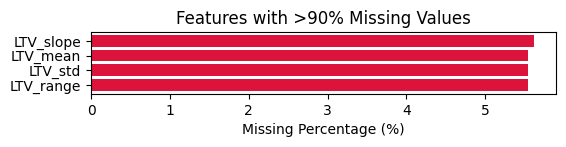

In [122]:
missing_counts = df_train.isna().sum()
missing_pct = (missing_counts / len(df_train)) * 100

# Keep only features with >90% missing
missing_df = pd.DataFrame({
    "Feature": missing_counts.index,
    "Missing %": missing_pct
})
missing_df = missing_df[missing_df["Missing %"] != 0].sort_values("Missing %", ascending=False)

# Plot
if not missing_df.empty:
    plt.figure(figsize=(6,0.8))
    plt.barh(missing_df["Feature"], missing_df["Missing %"], color="crimson")
    plt.xlabel("Missing Percentage (%)")
    plt.title("Features with >90% Missing Values")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No features with more than 90% missing values.")

In [123]:
df_train['LTV_MissFlag'] = df_train['LTV_mean'].isna().astype(int)
df_train['LTV_mean'] = df_train['LTV_mean'].fillna(df_train['LTV_mean'].median())
df_train['LTV_std'] = df_train['LTV_std'].fillna(0)
df_train['LTV_slope'] = df_train['LTV_slope'].fillna(0)
df_train['LTV_range'] = df_train['LTV_range'].fillna(0)

df_valid['LTV_MissFlag'] = df_valid['LTV_mean'].isna().astype(int)
df_valid['LTV_mean'] = df_valid['LTV_mean'].fillna(df_valid['LTV_mean'].median())
df_valid['LTV_std'] = df_valid['LTV_std'].fillna(0)
df_valid['LTV_slope'] = df_valid['LTV_slope'].fillna(0)
df_valid['LTV_range'] = df_valid['LTV_range'].fillna(0)

df_test['LTV_MissFlag'] = df_test['LTV_mean'].isna().astype(int)
df_test['LTV_mean'] = df_test['LTV_mean'].fillna(df_test['LTV_mean'].median())
df_test['LTV_std'] = df_test['LTV_std'].fillna(0)
df_test['LTV_slope'] = df_test['LTV_slope'].fillna(0)
df_test['LTV_range'] = df_test['LTV_range'].fillna(0)

In [124]:
missing_counts = df_train.isna().sum()
missing_pct = (missing_counts / len(df_train)) * 100

# Keep only features with >90% missing
missing_df = pd.DataFrame({
    "Feature": missing_counts.index,
    "Missing %": missing_pct
})
missing_df = missing_df[missing_df["Missing %"] != 0].sort_values("Missing %", ascending=False)

# Plot
if not missing_df.empty:
    plt.figure(figsize=(6,0.8))
    plt.barh(missing_df["Feature"], missing_df["Missing %"], color="crimson")
    plt.xlabel("Missing Percentage (%)")
    plt.title("Features with >90% Missing Values")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No features with more than 90% missing values.")

No features with more than 90% missing values.


In [135]:
df_train.to_csv("Data/prepro_train.csv", index = False)
df_valid.to_csv("Data/prepro_valid.csv", index = False)
df_test.to_csv("Data/prepro_test.csv", index = False)

In [158]:
df_train = pd.read_csv("Data/prepro_train.csv")
df_valid = pd.read_csv("Data/prepro_valid.csv")
df_test = pd.read_csv("Data/prepro_test.csv")

In [159]:
num_col = ['CreditScore', 'MI_Pct', 'OriginalCLTV',
       'OriginalDTI', 'OriginalUPB', 'OriginalLTV', 'OriginalInterestRate', 'OriginalLoanTerm', 'NumberOfBorrowers', 
       '0_1_UPB_Diff', '1_2_UPB_Diff', '2_3_UPB_Diff', '3_4_UPB_Diff',
       '4_5_UPB_Diff', '5_6_UPB_Diff', '6_7_UPB_Diff', '7_8_UPB_Diff',
       '8_9_UPB_Diff', '9_10_UPB_Diff', '10_11_UPB_Diff', '11_12_UPB_Diff',
       '12_13_UPB_Diff', 'UPB_std', 'UPB_trend', 'UPB_trend_pct', 'UPB_range',
       'longest_unchanged_UPB', 'avg_repayment_ratio', 'std_repayment_ratio',
       'pct_months_late', 'repayment_trend_slope', 'UPB_first_to_last_ratio',
       'Principal_reduction_rate', 'UPB_volatility', 'Amortization_slope',
       'UPB_rebound_count', 'UPB_autocorr', 'UPB_skew', 'UPB_kurtosis',
       'LTV_mean', 'LTV_std', 'LTV_slope', 'LTV_range', 'LTV_rebound_count',
       'Interest_rate_std', 'Interest_rate_slope', 'Early_repayment_ratio',
       'CreditScore_LTV_Ratio', 'CreditScore_DTI_Ratio', 'LTV_DTI_Product',
       'DebtServiceRatio', 'HighRiskCredit', 'HighLTV', 'HighDTI',
       'HighInterestRate','CompositeRiskScore']

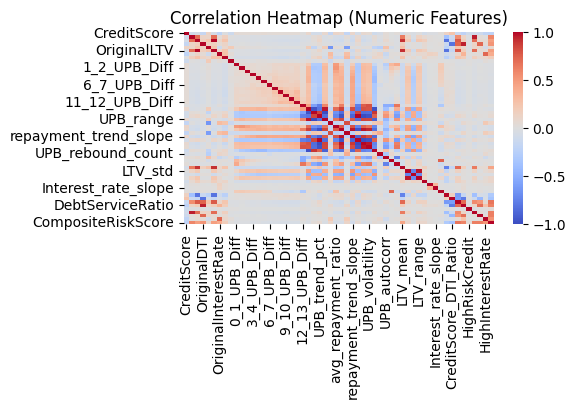


Highly correlated pairs (|corr| > 0.95):
                      Feature1                  Feature2  Correlation
1050             UPB_trend_pct   UPB_first_to_last_ratio     1.000000
111               OriginalCLTV               OriginalLTV     0.995175
1264  Principal_reduction_rate            UPB_volatility     0.968463
1421                   LTV_std                 LTV_range     0.968137
981                    UPB_std                 UPB_range     0.967907
1165       std_repayment_ratio  Principal_reduction_rate     0.965689
1163       std_repayment_ratio     repayment_trend_slope     0.964493
105                     MI_Pct                   HighLTV     0.956320
1164       std_repayment_ratio   UPB_first_to_last_ratio    -0.965689
1047             UPB_trend_pct       std_repayment_ratio    -0.965689
979                    UPB_std                 UPB_trend    -0.967901
1052             UPB_trend_pct            UPB_volatility    -0.968463
1241   UPB_first_to_last_ratio            UPB_vo

In [160]:
df_corr = df_train[num_col]

corr = df_corr.corr()

plt.figure(figsize=(5,2.5))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()
    
    # Extract and print highly correlated pairs
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    )

corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
    
high_corr = corr_pairs[abs(corr_pairs["Correlation"]) > 0.95]
print(f"\nHighly correlated pairs (|corr| > {0.95}):")
print(high_corr.sort_values("Correlation", ascending=False))

In [161]:
df_train['OriginalLTV_delta'] = df_train['OriginalCLTV'] - df_train['OriginalLTV']
df_valid['OriginalLTV_delta'] = df_valid['OriginalCLTV'] - df_valid['OriginalLTV']
df_test['OriginalLTV_delta'] = df_test['OriginalCLTV'] - df_test['OriginalLTV']

In [ ]:
corr_col = ['UPB_trend_pct', 'UPB_first_to_last_ratio', 'UPB_volatility', 'UPB_std', 'UPB_range', 'UPB_trend', 'LTV_range', 
            'std_repayment_ratio', 'repayment_trend_slope', 'OriginalCLTV']

df_train = df_train.drop(columns = corr_col)
df_valid = df_valid.drop(columns = corr_col)
df_test = df_test.drop(columns = corr_col)

In [163]:
for c in corr_col:
    num_col.remove(c)

num_col.append('OriginalLTV_delta')

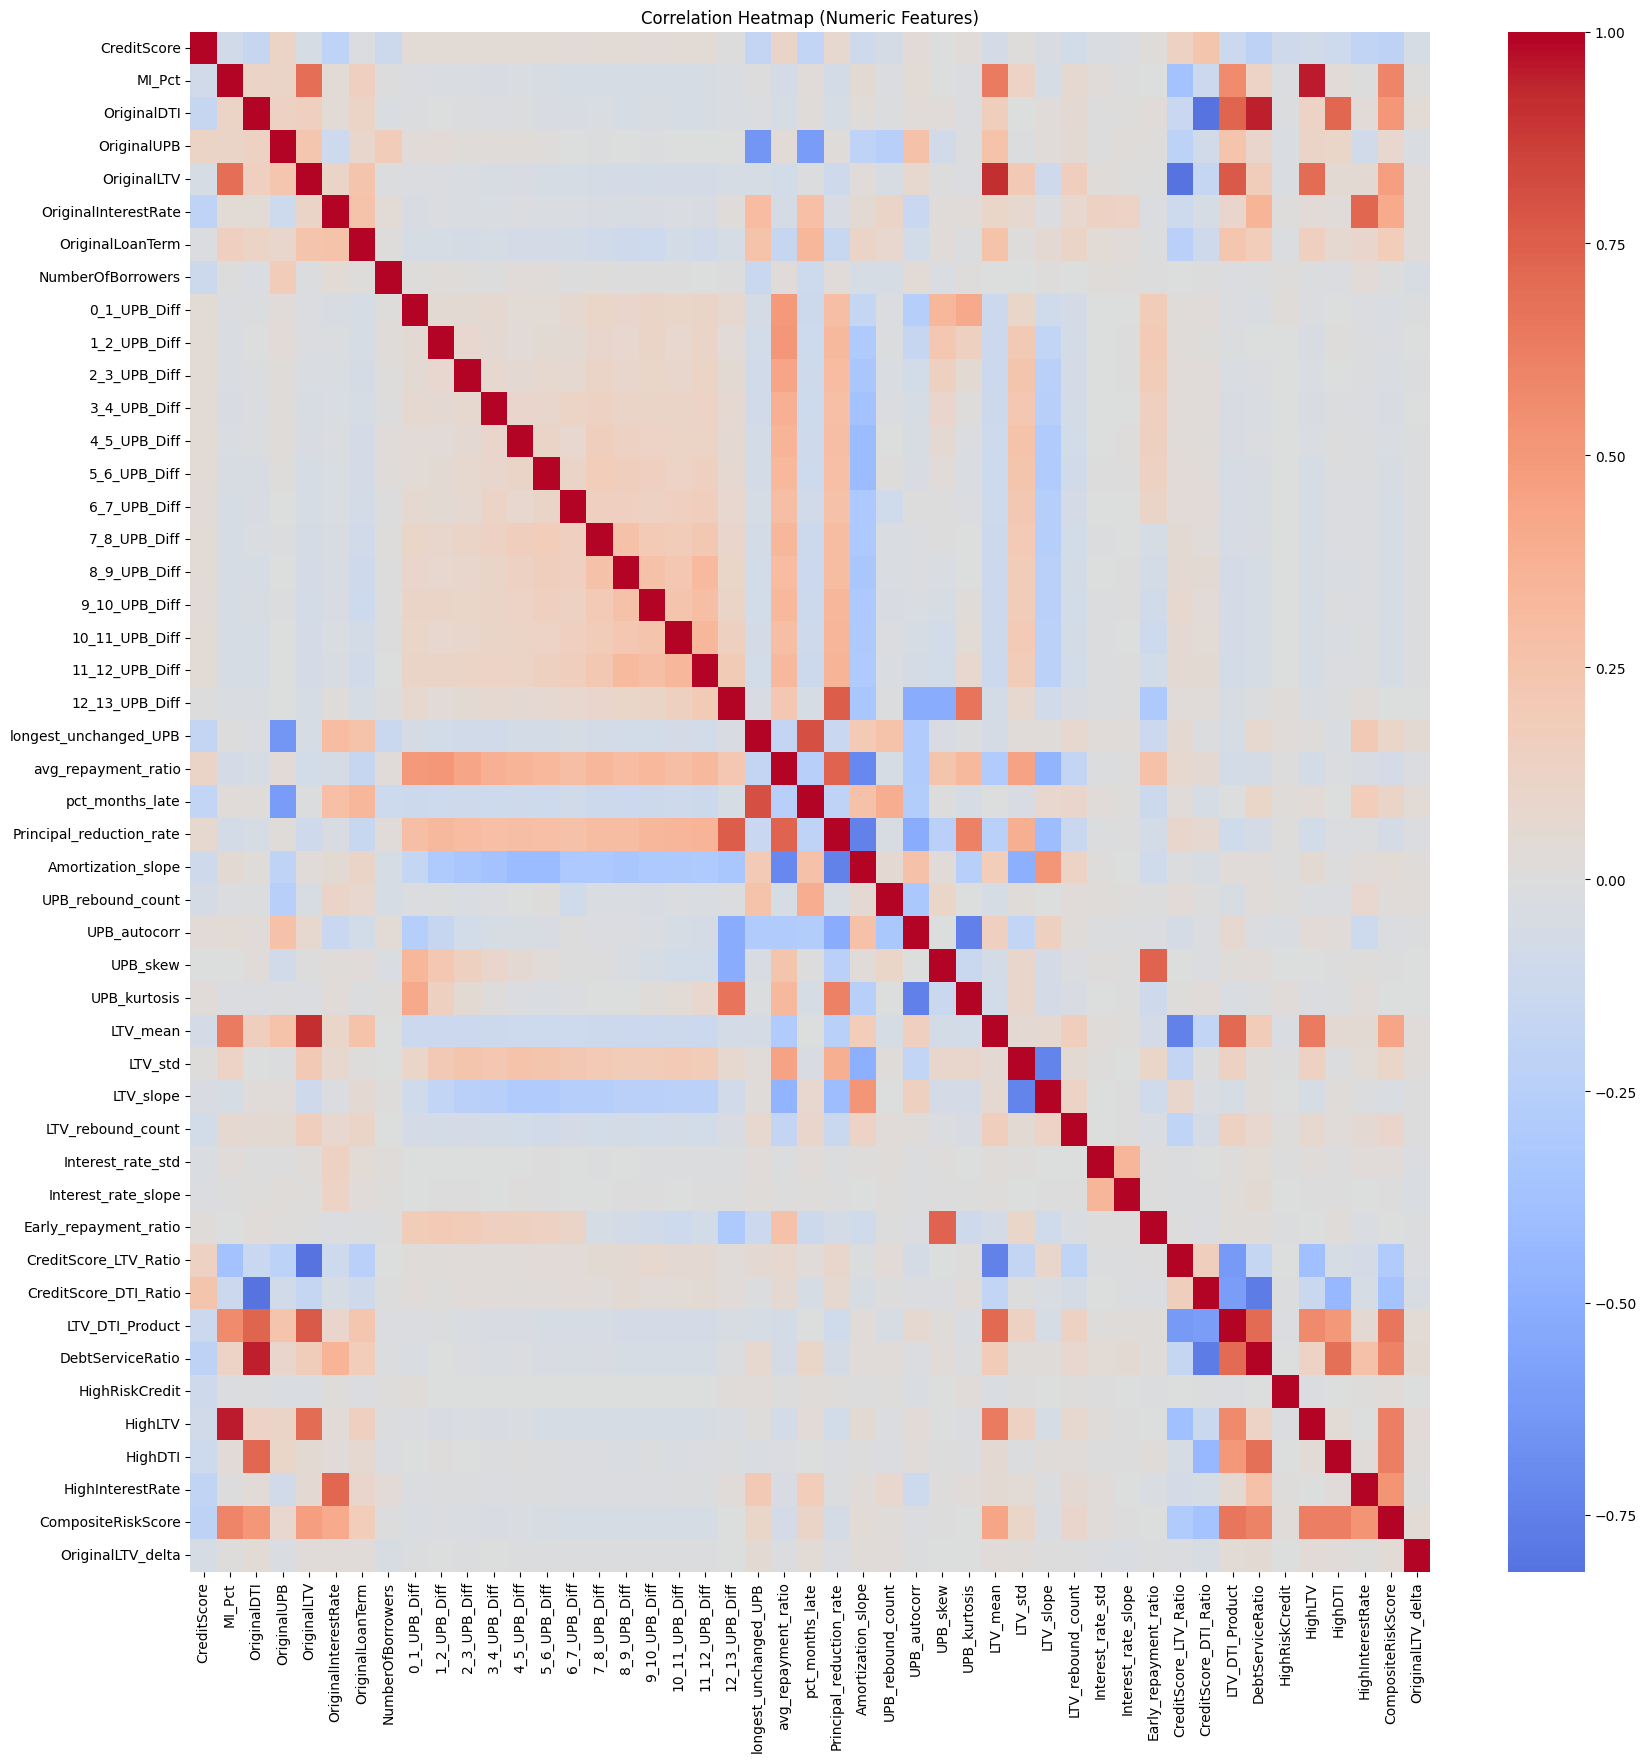


Highly correlated pairs (|corr| > 0.95):
   Feature1 Feature2  Correlation
86   MI_Pct  HighLTV      0.95632


In [172]:
df_corr = df_train[num_col]

corr = df_corr.corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()
    
    # Extract and print highly correlated pairs
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    )

corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
    
high_corr = corr_pairs[abs(corr_pairs["Correlation"]) > 0.95]
print(f"\nHighly correlated pairs (|corr| > {0.95}):")
print(high_corr.sort_values("Correlation", ascending=False))

In [156]:
df_train.columns

Index(['index', 'target', 'CreditScore', 'FirstTimeHomebuyerFlag', 'MSA',
       'MI_Pct', 'NumberOfUnits', 'OccupancyStatus', 'OriginalDTI',
       'OriginalUPB', 'OriginalLTV', 'OriginalInterestRate', 'Channel',
       'PropertyState', 'PropertyType', 'LoanPurpose', 'OriginalLoanTerm',
       'NumberOfBorrowers', 'SellerName', 'ServicerName',
       'SuperConformingFlag', 'ProgramIndicator', 'PropertyValMethod',
       'BalloonIndicator', 'CreditScore_MissFLag', 'OriginalDTI_MissFLag',
       '0_1_UPB_Diff', '1_2_UPB_Diff', '2_3_UPB_Diff', '3_4_UPB_Diff',
       '4_5_UPB_Diff', '5_6_UPB_Diff', '6_7_UPB_Diff', '7_8_UPB_Diff',
       '8_9_UPB_Diff', '9_10_UPB_Diff', '10_11_UPB_Diff', '11_12_UPB_Diff',
       '12_13_UPB_Diff', 'longest_unchanged_UPB', 'avg_repayment_ratio',
       'pct_months_late', 'Principal_reduction_rate', 'Amortization_slope',
       'UPB_rebound_count', 'UPB_autocorr', 'UPB_skew', 'UPB_kurtosis',
       'LTV_mean', 'LTV_std', 'LTV_slope', 'LTV_rebound_count',
    

In [5]:
cat_col = ['FirstTimeHomebuyerFlag', 'MSA', 'NumberOfUnits', 'OccupancyStatus', 'Channel',
       'PropertyState', 'PropertyType', 'LoanPurpose', 'SellerName', 'ServicerName',
       'SuperConformingFlag', 'ProgramIndicator', 'PropertyValMethod',
       'BalloonIndicator', 'CreditScore_MissFLag', 'OriginalDTI_MissFLag', 'HighRiskCredit', 'HighLTV', 'HighDTI',
       'HighInterestRate', 'LTV_MissFlag']

In [166]:
for c in cat_col:
    print(c, ": ", df_train[c].nunique())

FirstTimeHomebuyerFlag :  2
MSA :  412
NumberOfUnits :  4
OccupancyStatus :  3
Channel :  3
PropertyState :  54
PropertyType :  5
LoanPurpose :  3
SellerName :  20
ServicerName :  19
SuperConformingFlag :  2
ProgramIndicator :  3
PropertyValMethod :  5
BalloonIndicator :  3
CreditScore_MissFLag :  2
OriginalDTI_MissFLag :  2
HighRiskCredit :  2
HighLTV :  2
HighDTI :  2
HighInterestRate :  2
LTV_MissFlag :  2


In [169]:
for c in cat_col:
    if df_train[c].nunique() == 2:
        print(c, ": ", df_train[c].unique())

FirstTimeHomebuyerFlag :  ['N' 'Y']
SuperConformingFlag :  ['N' 'Y']
CreditScore_MissFLag :  [0 1]
OriginalDTI_MissFLag :  [0 1]
HighRiskCredit :  [0 1]
HighLTV :  [0 1]
HighDTI :  [0 1]
HighInterestRate :  [1 0]
LTV_MissFlag :  [1 0]


In [170]:
df_train['FirstTimeHomebuyerFlag'] = df_train['FirstTimeHomebuyerFlag'].replace({'Y':1, 'N':0})
df_valid['FirstTimeHomebuyerFlag'] = df_valid['FirstTimeHomebuyerFlag'].replace({'Y':1, 'N':0})
df_test['FirstTimeHomebuyerFlag'] = df_test['FirstTimeHomebuyerFlag'].replace({'Y':1, 'N':0})

df_train['SuperConformingFlag'] = df_train['SuperConformingFlag'].replace({'Y':1, 'N':0})
df_valid['SuperConformingFlag'] = df_valid['SuperConformingFlag'].replace({'Y':1, 'N':0})
df_test['SuperConformingFlag'] = df_test['SuperConformingFlag'].replace({'Y':1, 'N':0})

/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/694091243.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['FirstTimeHomebuyerFlag'] = df_train['FirstTimeHomebuyerFlag'].replace({'Y':1, 'N':0})
/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/694091243.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_valid['FirstTimeHomebuyerFlag'] = df_valid['FirstTimeHomebuyerFlag'].replace({'Y':1, 'N':0})
/var/folders/hd/1qp006zn48sdflzfg6_25rtr0000gn/T/ipykernel_25731/694091243.py:3: FutureWar

In [176]:
df_train.to_csv("Data/check_train.csv", index = False)
df_valid.to_csv("Data/check_valid.csv", index = False)
df_test.to_csv("Data/check_test.csv", index = False)

In [6]:
df_train = pd.read_csv("Data/check_train.csv")
df_valid = pd.read_csv("Data/check_valid.csv")
df_test = pd.read_csv("Data/check_test.csv")

In [7]:
for c in cat_col:
    print(c, ": ", df_train[c].nunique())

FirstTimeHomebuyerFlag :  2
MSA :  412
NumberOfUnits :  4
OccupancyStatus :  3
Channel :  3
PropertyState :  54
PropertyType :  5
LoanPurpose :  3
SellerName :  20
ServicerName :  19
SuperConformingFlag :  2
ProgramIndicator :  3
PropertyValMethod :  5
BalloonIndicator :  3
CreditScore_MissFLag :  2
OriginalDTI_MissFLag :  2
HighRiskCredit :  2
HighLTV :  2
HighDTI :  2
HighInterestRate :  2
LTV_MissFlag :  2


In [8]:
high_cardinality_features = ['MSA', 'PropertyState', 'SellerName', 'ServicerName']

for feature in high_cardinality_features:
    freq_encoding = df_train[feature].value_counts() / len(df_train)
    df_train[feature + '_freq_enc'] = df_train[feature].map(freq_encoding)

df_train.drop(columns=high_cardinality_features, inplace=True)

for feature in high_cardinality_features:
    freq_encoding = df_valid[feature].value_counts() / len(df_valid)
    df_valid[feature + '_freq_enc'] = df_valid[feature].map(freq_encoding)

df_valid.drop(columns=high_cardinality_features, inplace=True)

for feature in high_cardinality_features:
    freq_encoding = df_test[feature].value_counts() / len(df_test)
    df_test[feature + '_freq_enc'] = df_test[feature].map(freq_encoding)

df_test.drop(columns=high_cardinality_features, inplace=True)

In [9]:
ch = []

for col in high_cardinality_features:
    ch.append(col + '_freq_enc')

In [10]:
df_train.to_csv("Data/encode_train.csv", index = False)
df_valid.to_csv("Data/encode_valid.csv", index = False)
df_test.to_csv("Data/encode_test.csv", index = False)